<a href="https://colab.research.google.com/github/alealvaradoj131020/TextAnalytics_Proyecto/blob/main/ProyectoTextAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de sentimiento y modelado de tópicos**

**Proyecto Final Text Analytics - Master In Business Intelligence and Analytics**

Carlos Rivera - 251518

Daniel Cabrera - 252136

Alejandra Alvarado - 18263

## **1. Carga de datos**

¡Éxito! Dataset cargado.
El dataset tiene 20000 filas y 2 columnas.
                                          reviewText  Positive
0  This is a one of the best apps acording to a b...         1
1  This is a pretty good version of the game for ...         1
2  this is a really cool game. there are a bunch ...         1
3  This is a silly game and can be frustrating, b...         1
4  This is a terrific game on any pad. Hrs of fun...         1


/tmp/ipykernel_658/3201269415.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Positive', data=df, palette='viridis')


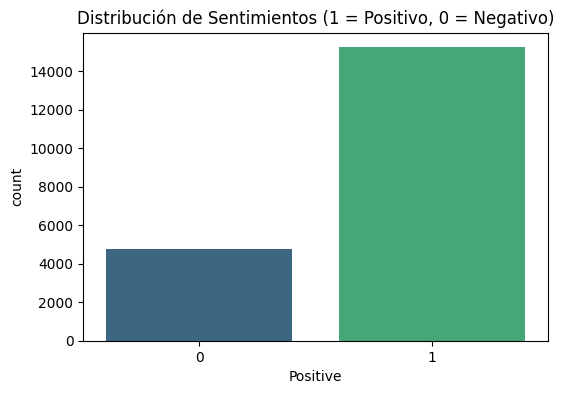

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv"

# Cargamos los datos
df = pd.read_csv(url)
print("¡Éxito! Dataset cargado.")
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# Mostramos las primeras 5 filas
print(df.head())

# Visualizamos si los datos están balanceados
plt.figure(figsize=(6,4))
sns.countplot(x='Positive', data=df, palette='viridis')
plt.title('Distribución de Sentimientos (1 = Positivo, 0 = Negativo)')
plt.show()

## **2. Pre-procesamiento de Datos**

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Cargamos las herramientas necesarias de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

# Definimos las palabras "vacías" (las que no queremos en el análisis)
stop_words = set(stopwords.words('english'))

# Inicializamos el Lematizador
lemmatizer = WordNetLemmatizer()

def limpiar_texto_avanzado(texto):
    # 1. Pasamos todo a minúsculas
    texto = str(texto).lower()

    # 2. Quitamos etiquetas HTML
    texto = re.sub(r'<.*?>', '', texto)

    # 3. Quitamos caracteres especiales y números
    texto = re.sub(r'<.*?>', '', texto)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    # 4. Tokenización
    palabras = nltk.word_tokenize(texto)

    # 5. Quitamos Stopwords y palabras muy cortas
    # También aplicamos Lematización a cada palabra
    palabras_limpias = [
        lemmatizer.lemmatize(p) for p in palabras
        if p not in stop_words and len(p) > 2
    ]

    # 6. Volvemos a unir las palabras en una sola cadena de texto
    return " ".join(palabras_limpias)

print("Iniciando limpieza de texto.")

# Creamos una nueva columna con el texto limpio
df['clean_text'] = df['reviewText'].apply(limpiar_texto_avanzado)

print("¡Limpieza completada!")

# Comparación de resultados
print("\n--- COMPARACIÓN DE RESULTADOS ---")
print(f"Original: {df['reviewText'].iloc[0][:100]}...")
print(f"Limpio:   {df['clean_text'].iloc[0][:100]}...")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Iniciando limpieza de texto.
¡Limpieza completada!

--- COMPARACIÓN DE RESULTADOS ---
Original: This is a one of the best apps acording to a bunch of people and I agree it has bombs eggs pigs TNT ...
Limpio:   one best apps acording bunch people agree bomb egg pig tnt king pig realustic stuff...


## **3. Visualización de Impacto**

/tmp/ipykernel_658/2996682631.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_p), y=list(words_p), ax=ax[1, 0], palette='Greens_r')
/tmp/ipykernel_658/2996682631.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_n), y=list(words_n), ax=ax[1, 1], palette='Reds_r')


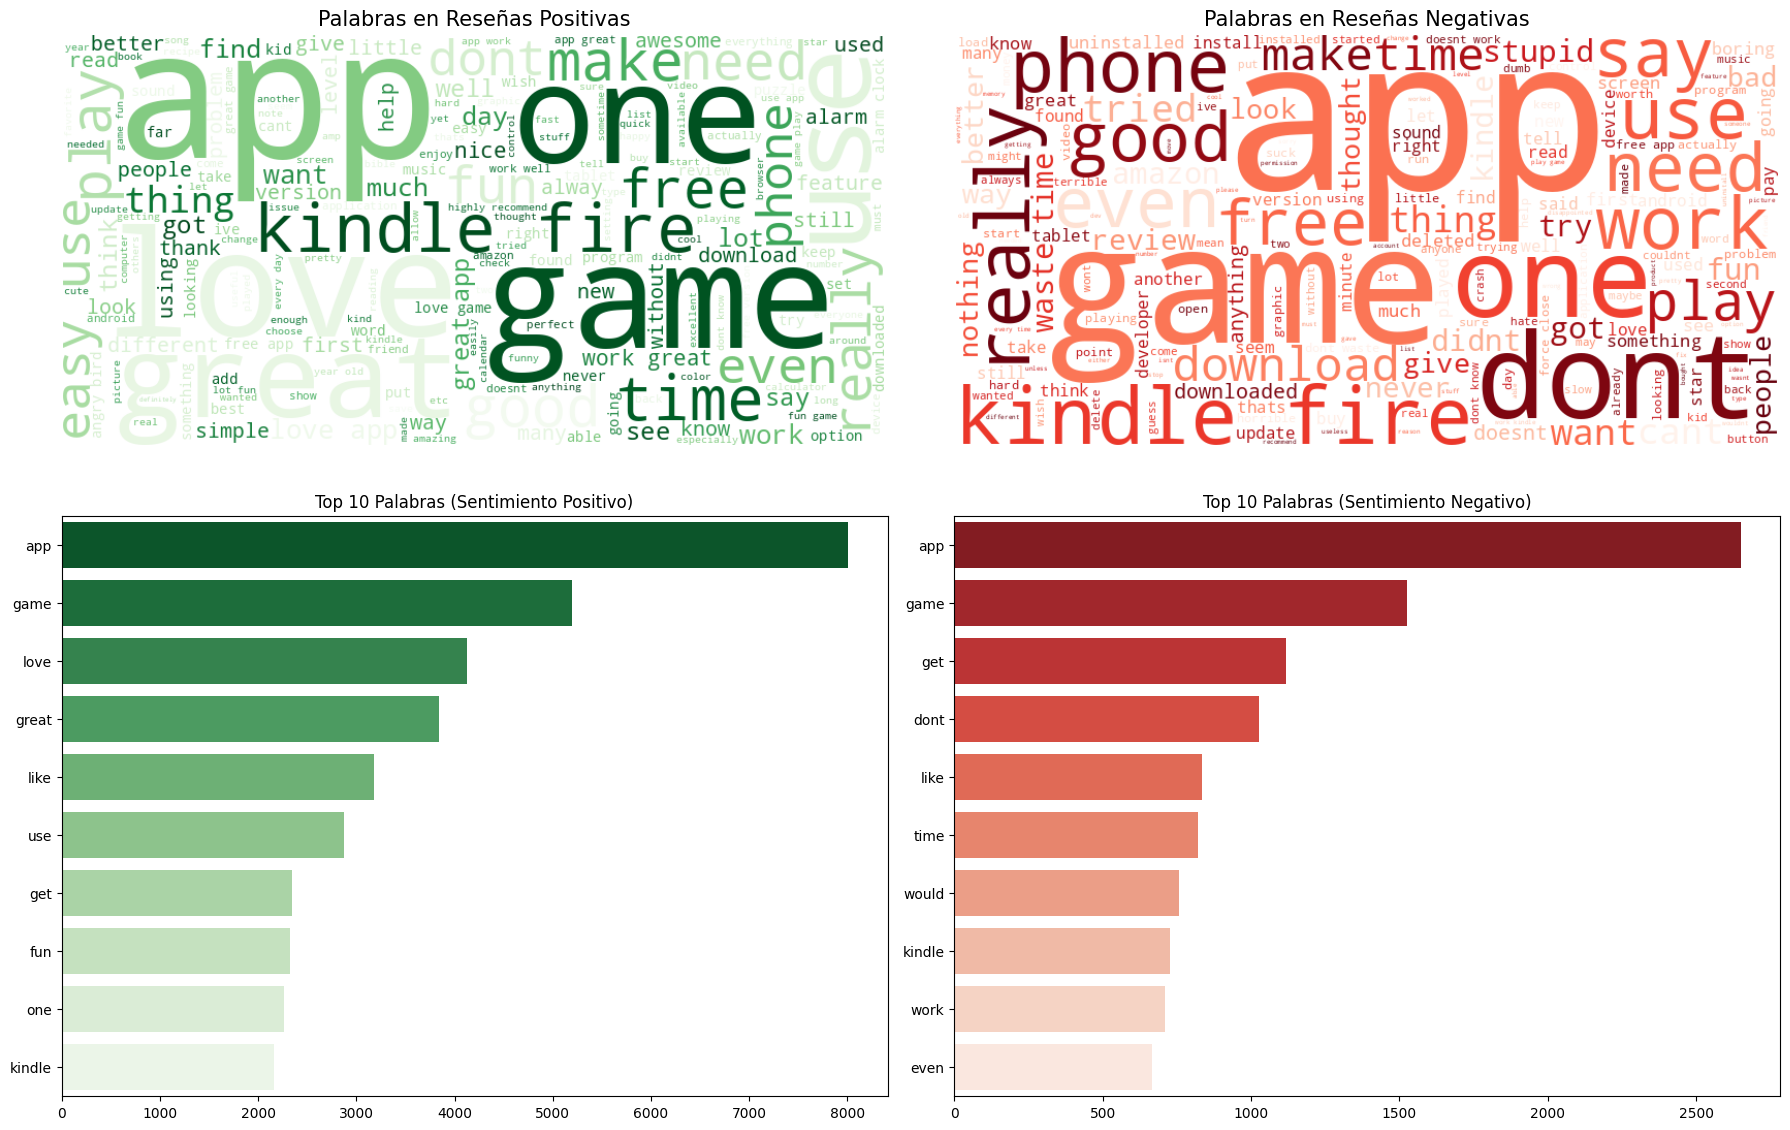


--- ANÁLISIS DE LOS RESULTADOS ---
Palabra más frecuente en positivos: 'app'
Palabra más frecuente en negativos: 'app'


In [7]:
from wordcloud import WordCloud
from collections import Counter

# Separamos los datos por sentimiento para compararlos
positivos = df[df['Positive'] == 1]['clean_text']
negativos = df[df['Positive'] == 0]['clean_text']

# Obtenemos las palabras más comunes
def obtener_frecuencias(dataset):
    todas_las_palabras = " ".join(dataset).split()
    return Counter(todas_las_palabras).most_common(10)

fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# 1. Nube de Palabras - Positivas
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(" ".join(positivos))
ax[0, 0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0, 0].set_title('Palabras en Reseñas Positivas', fontsize=15)
ax[0, 0].axis('off')

# 2. Nube de Palabras - Negativas
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(" ".join(negativos))
ax[0, 1].imshow(wordcloud_neg, interpolation='bilinear')
ax[0, 1].set_title('Palabras en Reseñas Negativas', fontsize=15)
ax[0, 1].axis('off')

# 3. Gráfico de Barras - Top 10 Positivas
top_pos = obtener_frecuencias(positivos)
words_p, counts_p = zip(*top_pos)
sns.barplot(x=list(counts_p), y=list(words_p), ax=ax[1, 0], palette='Greens_r')
ax[1, 0].set_title('Top 10 Palabras (Sentimiento Positivo)')

# 4. Gráfico de Barras - Top 10 Negativas
top_neg = obtener_frecuencias(negativos)
words_n, counts_n = zip(*top_neg)
sns.barplot(x=list(counts_n), y=list(words_n), ax=ax[1, 1], palette='Reds_r')
ax[1, 1].set_title('Top 10 Palabras (Sentimiento Negativo)')

plt.tight_layout()
plt.show()

print("\n--- ANÁLISIS DE LOS RESULTADOS ---")
print(f"Palabra más frecuente en positivos: '{top_pos[0][0]}'")
print(f"Palabra más frecuente en negativos: '{top_neg[0][0]}'")

## **4. Aplicación de Algoritmos de ML - Aprendizaje Supervisado**


>>> MÉTRICAS PARA NAIVE BAYES <<<
Precisión General (Accuracy): 0.8523
              precision    recall  f1-score   support

    Negativo       0.90      0.42      0.57      1411
    Positivo       0.85      0.99      0.91      4589

    accuracy                           0.85      6000
   macro avg       0.87      0.70      0.74      6000
weighted avg       0.86      0.85      0.83      6000


>>> MÉTRICAS PARA REGRESIÓN LOGÍSTICA <<<
Precisión General (Accuracy): 0.8887
              precision    recall  f1-score   support

    Negativo       0.85      0.64      0.73      1411
    Positivo       0.90      0.97      0.93      4589

    accuracy                           0.89      6000
   macro avg       0.88      0.80      0.83      6000
weighted avg       0.89      0.89      0.88      6000



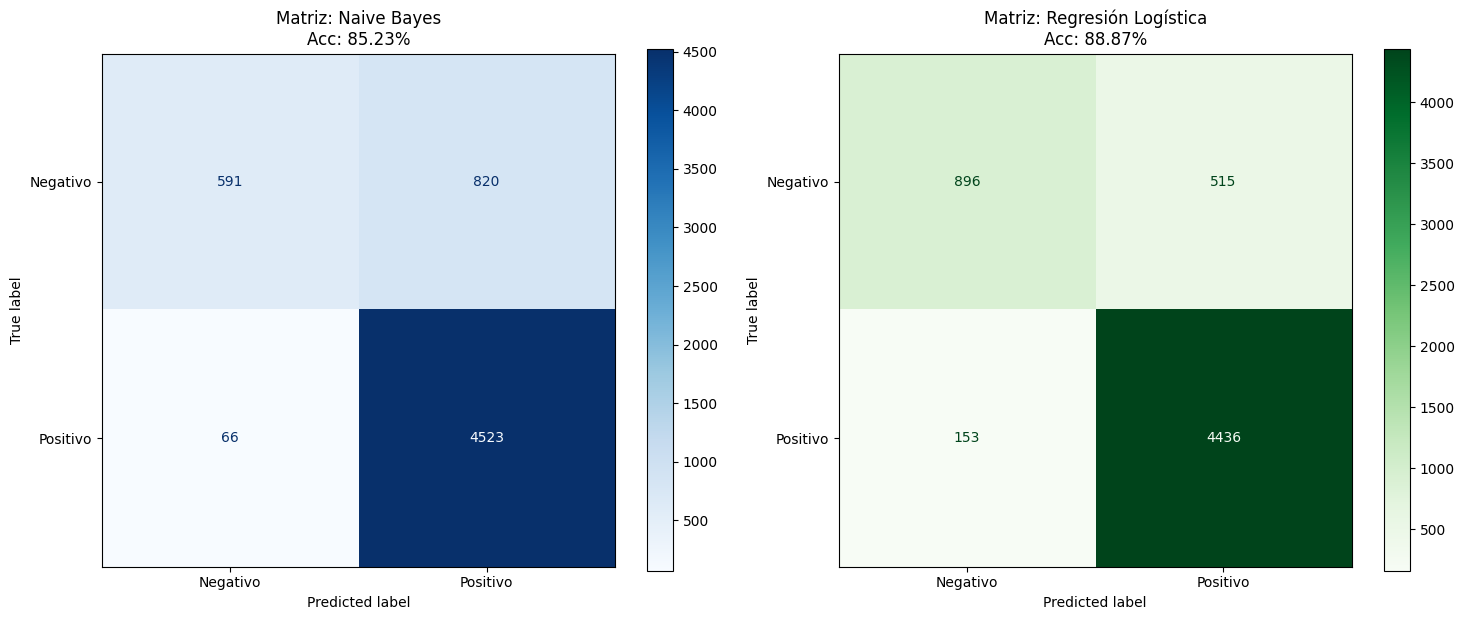


Observación: Tras la comparativa, el modelo con mejor desempeño es: **Regresión Logística**


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Convertimos el texto limpio en una matriz de números (TF-IDF)
vectorizador = TfidfVectorizer(max_features=5000)
X = vectorizador.fit_transform(df['clean_text'])
y = df['Positive']

# 70% Entrenamiento / 30% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Modelo 1: Naive Bayes
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train, y_train)
pred_nb = modelo_nb.predict(X_test)

# Modelo 2: Regresión Logística
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

# EVALUACIÓN DE AMBOS MODELOS

def mostrar_metricas(nombre, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n>>> MÉTRICAS PARA {nombre.upper()} <<<")
    print(f"Precisión General (Accuracy): {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Negativo', 'Positivo']))
    return acc

acc_nb = mostrar_metricas("Naive Bayes", y_test, pred_nb)
acc_lr = mostrar_metricas("Regresión Logística", y_test, pred_lr)

# COMPARATIVA VISUAL (Matrices de Confusión)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Matriz para Naive Bayes
ConfusionMatrixDisplay.from_predictions(y_test, pred_nb,
                                        display_labels=['Negativo', 'Positivo'],
                                        cmap='Blues', ax=ax[0])
ax[0].set_title(f'Matriz: Naive Bayes\nAcc: {acc_nb:.2%}')

# Matriz para Regresión Logística
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr,
                                        display_labels=['Negativo', 'Positivo'],
                                        cmap='Greens', ax=ax[1])
ax[1].set_title(f'Matriz: Regresión Logística\nAcc: {acc_lr:.2%}')

plt.tight_layout()
plt.show()

# --- Observaciones ---
mejor = "Naive Bayes" if acc_nb > acc_lr else "Regresión Logística"
print(f"\nObservación: Tras la comparativa, el modelo con mejor desempeño es: **{mejor}**")

## **5. Modelado de Tópicos (LDA) - Aprendizaje No Supervisado**

In [15]:
!pip install gensim
import gensim
from gensim import corpora

# 1. Preparamos los datos para LDA
textos_divididos = [texto.split() for texto in df['clean_text']]

# 2. Creamos un diccionario
diccionario = corpora.Dictionary(textos_divididos)

# Filtramos palabras:
# - Que aparezcan en menos de 5 reseñas (muy raras)
# - Que aparezcan en más del 50% de las reseñas (muy comunes/sin valor)
diccionario.filter_extremes(no_below=5, no_above=0.5)

# 3. Creamos el Corpus: Una "bolsa de palabras" (Bag of Words) para cada reseña
corpus = [diccionario.doc2bow(text) for text in textos_divididos]

# 4. Entrenamos el modelo LDA para encontrar 5 temas ocultos
print("Buscando temas ocultos en las reseñas, esto puede tomar un minuto.")
lda_model = gensim.models.LdaModel(corpus=corpus, id2word=diccionario,
                                   num_topics=5, random_state=42, passes=10)

# 5. Mostramos los temas encontrados con sus 10 palabras más importantes
print("\n--- LOS 5 TEMAS PRINCIPALES DETECTADOS ---")
print("La IA encontró que las reseñas hablan principalmente de estos 5 grupos de palabras:\n")

for idx, topic in lda_model.print_topics(-1):
    # Limpiamos un poco el formato para que sea legible
    palabras_clave = topic.split('"')[1::2]
    print(f"Tema #{idx+1}: {', '.join(palabras_clave)}")


Buscando temas ocultos en las reseñas, esto puede tomar un minuto.

--- LOS 5 TEMAS PRINCIPALES DETECTADOS ---
La IA encontró que las reseñas hablan principalmente de estos 5 grupos de palabras:

Tema #1: app, kindle, work, fire, great, use, alarm, love, option, well
Tema #2: app, dont, get, would, time, like, kindle, even, say, work
Tema #3: game, fun, play, love, like, get, great, time, really, playing
Tema #4: app, use, love, easy, great, like, recommend, bible, make, read
Tema #5: app, free, version, one, phone, apps, amazon, work, android, need


/tmp/ipykernel_658/2355547692.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pesos, y=palabras, ax=axes[i], palette='viridis')
/tmp/ipykernel_658/2355547692.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pesos, y=palabras, ax=axes[i], palette='viridis')
/tmp/ipykernel_658/2355547692.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pesos, y=palabras, ax=axes[i], palette='viridis')
/tmp/ipykernel_658/2355547692.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

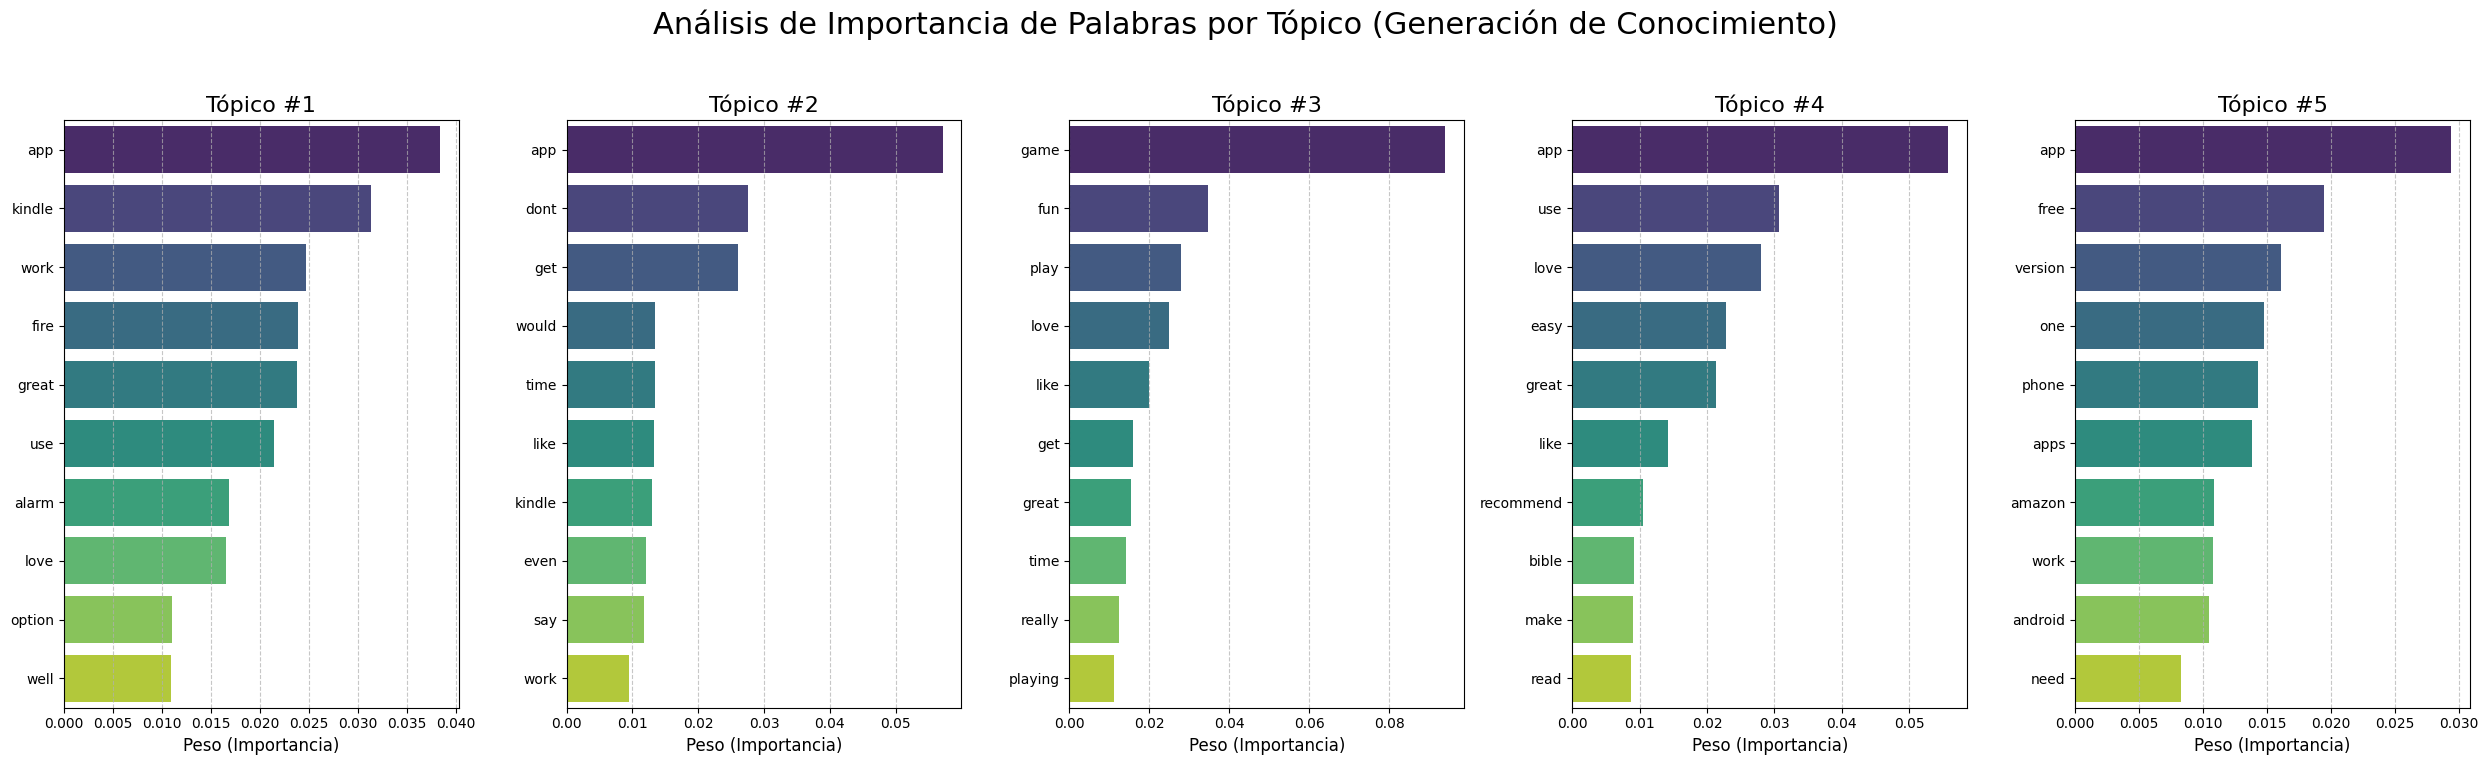

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos los datos de los tópicos del modelo LDA
topics = lda_model.show_topics(formatted=False, num_words=10)

fig, axes = plt.subplots(1, 5, figsize=(25, 8), sharey=False)
fig.suptitle('Análisis de Importancia de Palabras por Tópico (Generación de Conocimiento)', fontsize=22)

# Iteramos sobre cada tópico para crear su gráfica
for i, (topic_num, words) in enumerate(topics):
    # Separamos las palabras y sus pesos (probabilidades)
    palabras = [w[0] for w in words]
    pesos = [w[1] for w in words]

    # Creamos la gráfica de barras horizontal
    sns.barplot(x=pesos, y=palabras, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Tópico #{i+1}', fontsize=16)
    axes[i].set_xlabel('Peso (Importancia)', fontsize=12)
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
